## <center>Import des modules</center>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('preprocessing.csv')
pd.set_option('display.max_columns', None)

In [3]:
#Reformatage des colonnes de dates en format datetime

df['Created_at'] = pd.to_datetime(df['Created_at'])
df['Customer since'] = pd.to_datetime(df['Customer since']).dt.to_period('M')

In [4]:
df.head()

,Customer_id,Customer since,Item_id,Increment_id,Sales_commission_code,Qty_ordered,Price,Discount_amount,Net_income,Payment_method,Created_at,Year,Month,Category,Bi_status,Status,Regroupement_status,Regroupement_payment_method,Taux_change,Discount_amount_euros,Net_income_euros,Price_euros
0,4,2016-07,211135,100147446,R-FSD-52352,1,360.0,300.0,60.0,cod,2016-07-01,2016,7,Beauty & Grooming,Net,complete,finalisé,cod,0.008686,2.61,0.52,3.13
1,11,2016-07,211145,100147455,105259,1,120.0,0.0,120.0,ublcreditcard,2016-07-01,2016,7,Home & Living,Net,complete,finalisé,paiement immédiat,0.008686,0.00,1.04,1.04
2,11,2016-07,211147,100147457,105259,1,1550.0,0.0,1550.0,ublcreditcard,2016-07-01,2016,7,Men's Fashion,Gross,canceled,annulé,paiement immédiat,0.008686,0.00,13.46,13.46
3,13,2016-07,211149,100147458,R-KHW-104406,1,420.0,0.0,1270.0,cod,2016-07-01,2016,7,Soghaat,Net,complete,finalisé,cod,0.008686,0.00,11.03,3.65
4,13,2016-07,211150,100147458,R-KHW-104406,1,360.0,0.0,1270.0,cod,2016-07-01,2016,7,Soghaat,Net,complete,finalisé,cod,0.008686,0.00,11.03,3.13


## <center>Etudes statistiques et relations entre les variables</center>

##### Analyse de la relation entre les différentes variables numériques

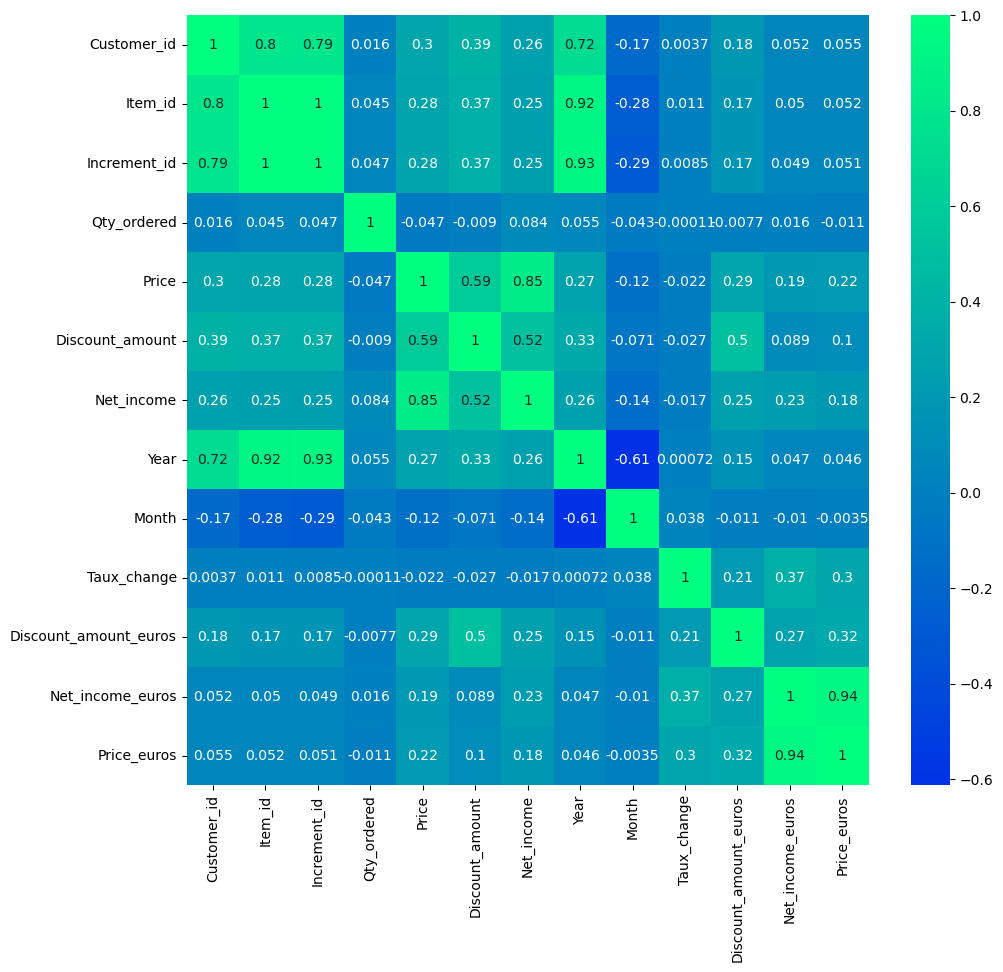

In [5]:
# Matrice de corrélation du DataFrame
plt.figure(figsize=(11, 10))
sns.heatmap(df.corr(), annot=True, center=0, cmap='winter');

Nous remarquons que les deux variables numériques les plus corrélées entre elles sont les variables 'net_income_euros' et 'price_euros'.

###### Analyse de la relation entre les variables "Price_euros" et "Category" (test ANOVA)  

In [6]:
import statsmodels.api

resultat = statsmodels.formula.api.ols("Price_euros ~ Category", data =df).fit()
table=statsmodels.api.stats.anova_lm(resultat)
table

,df,sum_sq,mean_sq,F,PR(>F)
Category,14.0,6.711840e+08,4.794171e+07,114.001571,0.0
Residual,106723.0,4.488081e+10,4.205355e+05,NaN,NaN


 La p value est à 0 ce qui indique une forte corrélation entre la variable prix et la variable catégorie

###### Analyse de la relation entre les variables "Net_income_euros" et "Category" (test ANOVA)  

In [7]:
import statsmodels.api
result = statsmodels.formula.api.ols('Net_income_euros ~ Category', data = df).fit()
table = statsmodels.api.stats.anova_lm(result)
table


,df,sum_sq,mean_sq,F,PR(>F)
Category,14.0,6.125728e+08,4.375520e+07,86.862653,1.764251e-249
Residual,106723.0,5.375942e+10,5.037286e+05,NaN,NaN


La p-value est très proche de 0, donc on rejette l'hypothèse selon laquelle 'category' n'influe pas sur 'net_income_euros'. Conclusion la variable 'category' a un effet statistique significatif sur la variable 'net_income_euros'.


###### Analyse de la relation entre les variables "Qty_ordered" et "Category" (test ANOVA)  

In [8]:
result = statsmodels.formula.api.ols('Qty_ordered ~ Category', data = df).fit()
table = statsmodels.api.stats.anova_lm(result)
table


,df,sum_sq,mean_sq,F,PR(>F)
Category,14.0,5182.738701,370.195622,165.101356,0.0
Residual,106723.0,239297.775830,2.242232,NaN,NaN


La p-value est égale à de 0, donc on rejette l'hypothèse selon laquelle 'category' n'influe pas sur 'qty_ordered'. Conclusion la variable 'category' a un effet statistique significatif sur la variable 'qty_ordered'.


###### Analyse de la relation entre les variables "Category" et "Customer_id" (tests Khi2 et V de Cramer)  

In [9]:
from scipy.stats import chi2_contingency

# Table de contingence
table = pd.crosstab(df['Category'], df['Customer_id'])

# Test du  χ2 sur la table de contingence
test_chi2 = chi2_contingency(table)

# Affichage de la statistique du test, la p-value et le degré de liberté
statistique = test_chi2[0]
p_value = test_chi2[1]
degré_de_liberté = test_chi2[2]

print("statistique:", test_chi2[0])
print("p-value:", test_chi2[1])
print("degré de liberté:", test_chi2[2])

# V de cramer
def V_cramer(table, N):
    chi_2 = chi2_contingency(table)[0]
    k = table.shape[0]
    r = table.shape[1]
    k_corr = k - (k - 1)**2 / (N - 1)
    r_corr = r - (r - 1)**2 / (N - 1)
    phi_2 = max(0, (chi_2 / N) - ((k - 1) * (r - 1)) / (N - 1))
    v = np.sqrt(phi_2 / min(k_corr - 1, r_corr - 1))
    return v

print("coefficient v-cramer:", V_cramer(table, df.shape[0]))

statistique: 492756.0331741627
p-value: 0.0
degré de liberté: 192892
coefficient v-cramer: 0.44798741687326027


Le test du χ2 nous révèle une p-value de 0, donc <5%. On rejette donc totalement l'hypothèse selon laquelle 'Customer_ID' et 'category' sont indépendantes.

Le coefficient de Cramer est de 0.44. Ce n'est pas élevé, il n'y a donc pas de forte corrélation entre les deux variables. Cependant, celle-ci n'est pas non plus négligeable.


###### Analyse de la relation entre les variables "Sales_commission_code" et "Customer_id" (tests Khi2 et V de Cramer)  

In [10]:
# Table de contingence
table = pd.crosstab(df['Sales_commission_code'], df['Customer_id'])

# Test du  χ2 sur la table de contingence
test_chi2 = chi2_contingency(table)

# Affichage de la statistique du test, la p-value et le degré de liberté
statistique = test_chi2[0]
p_value = test_chi2[1]
degré_de_liberté = test_chi2[2]

print("statistique:", test_chi2[0])
print("p-value:", test_chi2[1])
print("degré de liberté:", test_chi2[2])

# Calcul du coefficient de cramer
def V_cramer(table, N):
    chi_2 = chi2_contingency(table)[0]
    k = table.shape[0]
    r = table.shape[1]
    k_corr = k - (k - 1)**2 / (N - 1)
    r_corr = r - (r - 1)**2 / (N - 1)
    phi_2 = max(0, (chi_2 / N) - ((k - 1) * (r - 1)) / (N - 1))
    v = np.sqrt(phi_2 / min(k_corr - 1, r_corr - 1))
    return v

print("coefficient v-cramer:", V_cramer(table, df.shape[0]))

statistique: 374186615.37659544
p-value: 0.0
degré de liberté: 98829594
coefficient v-cramer: 0.6209315532094056


Le test du χ2 nous révèle une p-value de 0, donc <5%. On rejette donc totalement l'hypothèse selon laquelle 'Customer_ID' et 'sales_commission_code' sont indépendantes.

Le coefficient de Cramer est de 0.62. Il y a une corrélation certaine entre les deux variables.


###### Analyse de la relation entre les variables "Net_income_euros" et "Customer_id" (test de Pearson)  

In [11]:
# Test de Pearson entre les variables 'net_income_euros' et 'Customer_ID'
from scipy.stats import pearsonr

test_pearson = pearsonr(df['Net_income_euros'], df['Customer_id'])

print("Coefficient:", test_pearson[0])
print("p-value:", test_pearson[1])

Coefficient: 0.051785986460463306
p-value: 2.701585921114484e-64


Le coefficient est proche de 0, il n'y a donc pas de corrélation entre 'net_income_euros' et 'Customer_ID'.

Cependant, la p-value est proche de 0, donc <5%. La variable 'Customer_ID' a un effet statistique significatif sur la variable 'net_income_euros'.

##### Etude de la variable 'Regroupement_status'

In [12]:
# Visualisation des statuts des commande en fonction des catégories

df.groupby(by='Category').agg({'Regroupement_status':'value_counts'})

Regroupement_status
Category           Regroupement_status                     
Appliances         finalisé                            6719
                   annulé                              4911
                   en attente                            12
Beauty & Grooming  finalisé                            7807
                   annulé                              2199
                   en attente                            46
Books              finalisé                             130
                   annulé                                32
                   en attente                            12
Computing          annulé                               690
                   finalisé                             534
                   en attente                             6
Entertainment      finalisé                            4718
                   annulé                              3369
                   en attente                             5
Health & Sports    finalisé                            1021
                   annulé                               507
                   en attente                            16
Home & Living      finalisé                            2112
                   annulé                              1070
                   en attente                            37
Kids & Baby        finalisé                            1688
                   annulé                               742
                   en attente                            13
Men's Fashion      finalisé                           11989
                   annulé                              6954
                   en attente                            67
Mobiles & Tablets  finalisé                           15173
                   annulé                             11000
                   en attente                            34
Others             annulé                               372
                   finalisé                             310
                   en attente                            17
School & Education finalisé                             163
                   annulé                                94
                   en attente                             3
Soghaat            finalisé                            7836
                   annulé                              1503
                   en attente                            20
Superstore         finalisé                            4693
                   annulé                              1657
                   en attente                            87
Women's Fashion    finalisé                            4071
                   annulé                              2245
                   en attente                            54

A première vue, les commandes annulées représentent un pourcentage majoritaire par rapport à l'ensemble des commandes.
Il serait intéressant de savoir pourquoi est-ce que la majorité des commandes ne sont pas finalisées.
Y-a-t-il un lien avec le fait qu'il s'agisse d'un marché e-commerce ?

In [13]:
df2 = pd.crosstab(df['Category'], df['Regroupement_status'], normalize=0).round(2)
df2

Regroupement_status,annulé,en attente,finalisé
Category,,,
Appliances,0.42,0.00,0.58
Beauty & Grooming,0.22,0.00,0.78
Books,0.18,0.07,0.75
Computing,0.56,0.00,0.43
Entertainment,0.42,0.00,0.58
Health & Sports,0.33,0.01,0.66
Home & Living,0.33,0.01,0.66
Kids & Baby,0.30,0.01,0.69
Men's Fashion,0.37,0.00,0.63


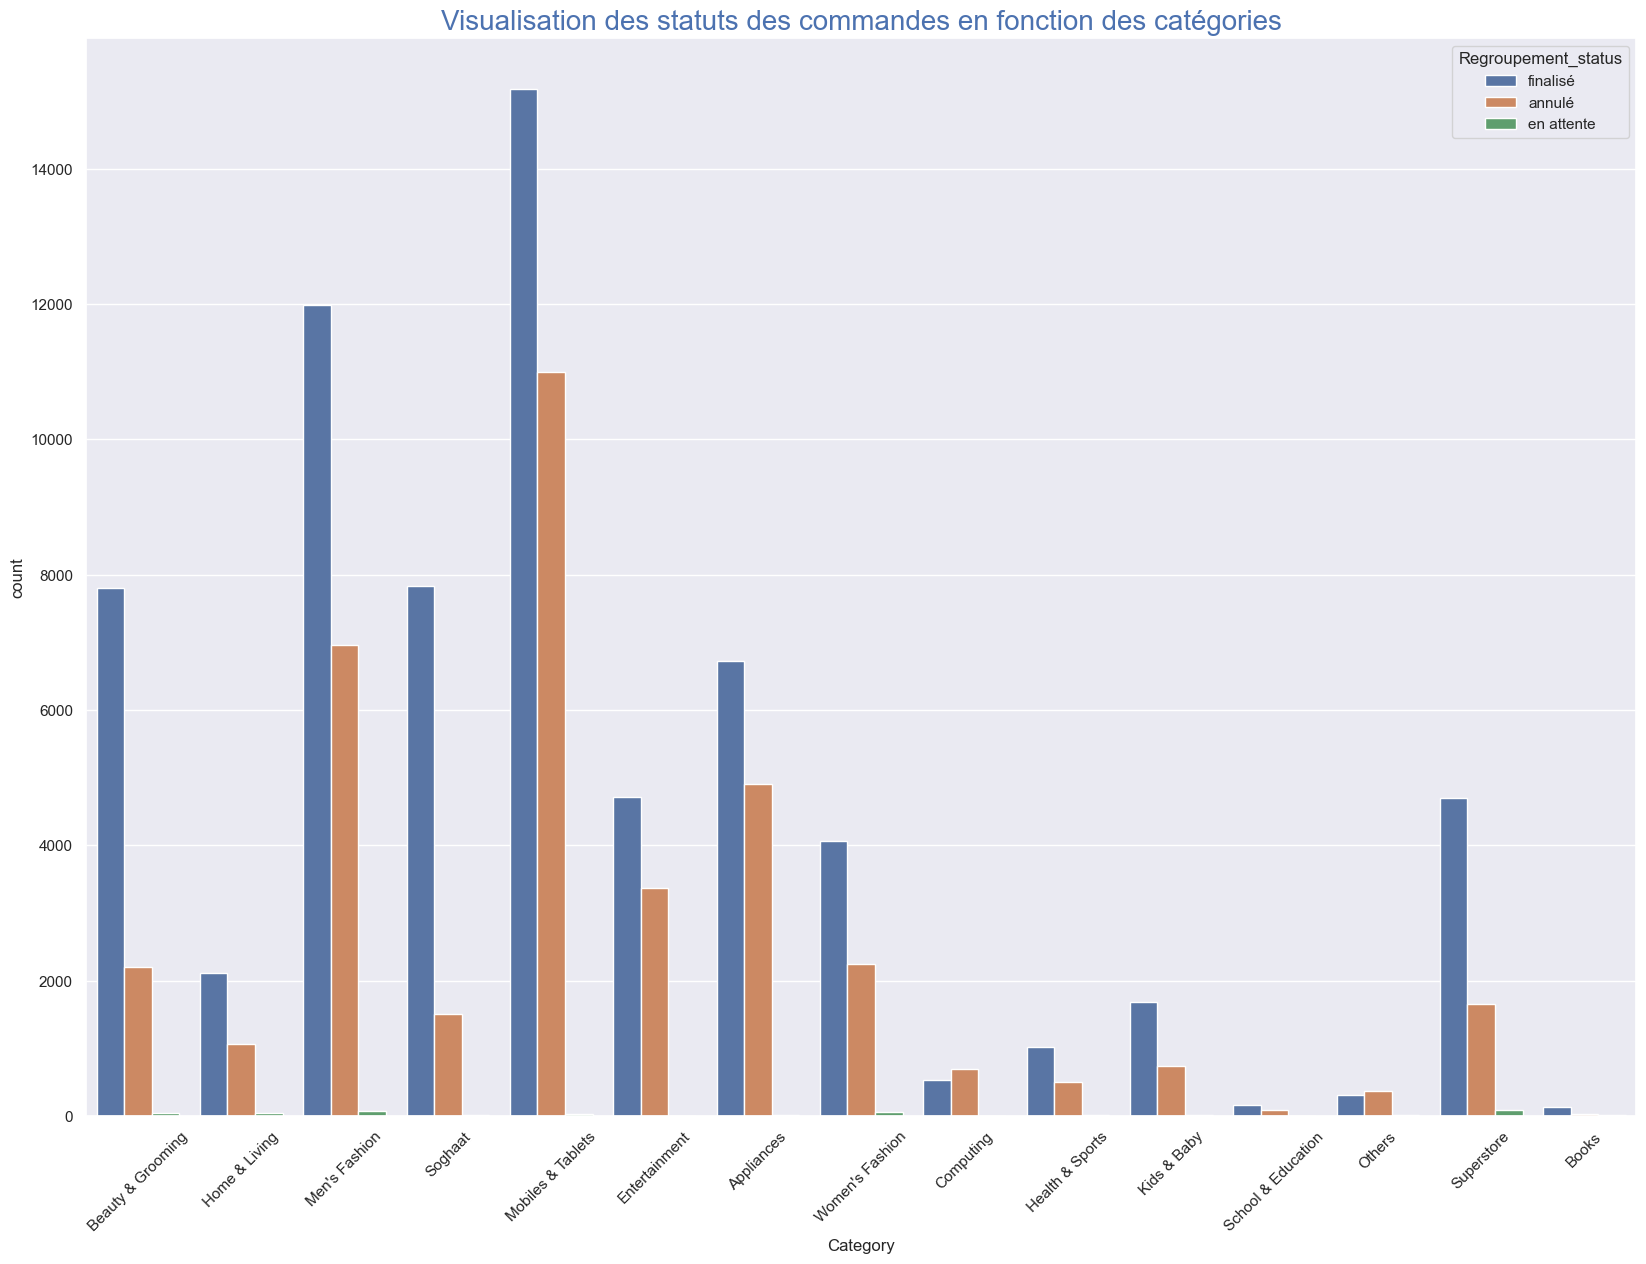

In [14]:
sns.set_theme()
plt.figure(figsize=(20, 14))
sns.countplot(x='Category', hue='Regroupement_status', data=df)
plt.xticks(rotation=45)
plt.title('Visualisation des statuts des commandes en fonction des catégories', fontsize=20, color='b');

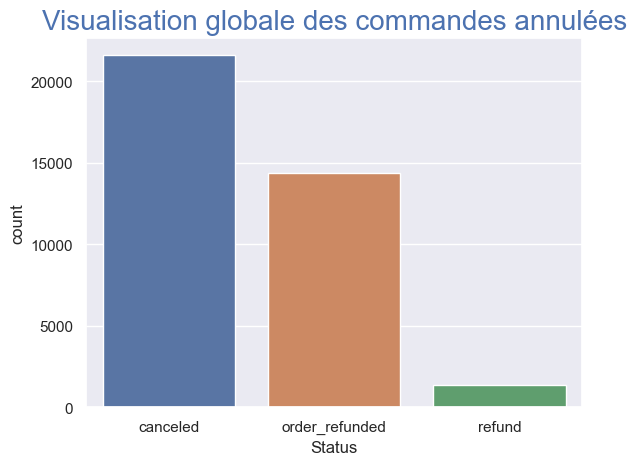

In [15]:
sns.countplot(x='Status',  data=df[df['Regroupement_status']=='annulé'])
plt.title('Visualisation globale des commandes annulées', fontsize=20, color='b');

L'ensemble des catégories sont impactées à différents degrés par les annulations de commandes.

##### Etude de la variable 'price'

- Visualisation des valeurs extrêmes

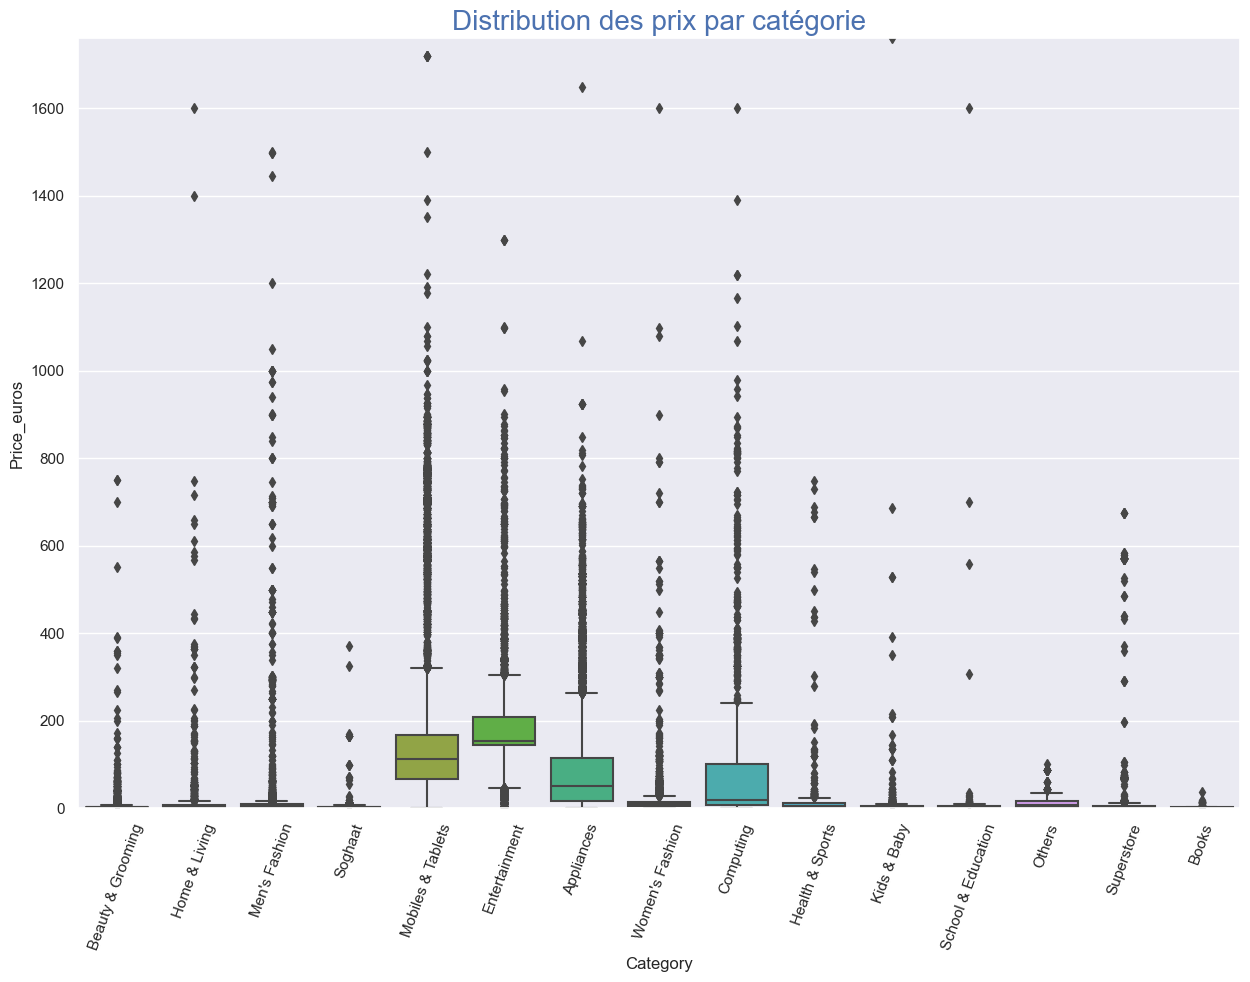

In [16]:
plt.figure(figsize=(15, 10))
sns.boxplot('Category', 'Price_euros', data=df)
plt.xticks(rotation =70)
plt.title("Distribution des prix par catégorie", fontsize=20, color="b")
plt.ylim(0,1760);  # 1760 correspond à price_euros max

<Figure size 1000x1000 with 0 Axes>

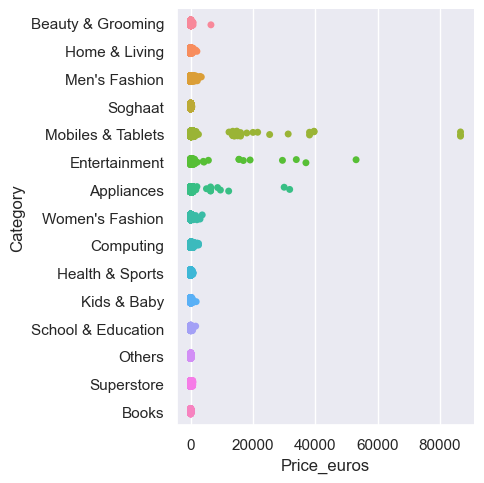

In [17]:
plt.figure(figsize = (10,10))
sns.catplot(data =df, y="Category", x="Price_euros");

In [18]:
df["Price_euros"].describe()

count    106738.000000
mean         77.619524
std         653.275276
min           0.000000
25%           2.920000
50%           8.590000
75%         103.940000
max       86597.000000
Name: Price_euros, dtype: float64

Nous constatons la présense de nombreuses valeurs extrêmes dans le dataset.

In [19]:
df.loc[df["Price_euros"] ==df["Price_euros"].max()]

,Customer_id,Customer since,Item_id,Increment_id,Sales_commission_code,Qty_ordered,Price,Discount_amount,Net_income,Payment_method,Created_at,Year,Month,Category,Bi_status,Status,Regroupement_status,Regroupement_payment_method,Taux_change,Discount_amount_euros,Net_income_euros,Price_euros
68661,62249,2017-10,617258,100380991,CFSD30642,1,86597.0,0.0,86597.0,Easypay,2017-11-16,2017,11,Mobiles & Tablets,Valid,order_refunded,annulé,paiement immédiat,1.0,0.0,86597.0,86597.0
68665,65854,2017-11,617268,100380995,CRWP31924,1,86597.0,0.0,86597.0,Easypay,2017-11-16,2017,11,Mobiles & Tablets,Gross,canceled,annulé,paiement immédiat,1.0,0.0,86597.0,86597.0
68666,65854,2017-11,617271,100380997,CRWP31924,1,86597.0,0.0,86597.0,Easypay,2017-11-16,2017,11,Mobiles & Tablets,Gross,canceled,annulé,paiement immédiat,1.0,0.0,86597.0,86597.0


La visualisation des valeurs extrêmes positives, nous amène à conclure qu'il s'agit d'opérations annulées et remboursées mais ne présentant pas de caractère anormal. Nous décidons donc de conserver ces valeurs.

In [20]:
df.loc[df["Price_euros"] ==df["Price_euros"].min()]

,Customer_id,Customer since,Item_id,Increment_id,Sales_commission_code,Qty_ordered,Price,Discount_amount,Net_income,Payment_method,Created_at,Year,Month,Category,Bi_status,Status,Regroupement_status,Regroupement_payment_method,Taux_change,Discount_amount_euros,Net_income_euros,Price_euros
1297,820,2016-07,215353,100150387,33030,2,0.15,0.0,0.30,cod,2016-07-16,2016,7,School & Education,Net,complete,finalisé,cod,0.008712,0.00,0.00,0.0
3626,2247,2016-07,220494,100154287,C-MUX102551,1,0.00,0.0,0.00,cod,2016-07-29,2016,7,Kids & Baby,Gross,canceled,annulé,cod,0.008725,0.00,0.00,0.0
19561,64,2016-07,282675,100195853,c hdd 30040,1,0.00,0.0,0.00,cod,2016-11-18,2016,11,Men's Fashion,Gross,canceled,annulé,cod,0.009017,0.00,0.00,0.0
19573,6573,2016-09,282815,100195920,R-LHE-106931,2,0.00,0.0,0.00,cod,2016-11-18,2016,11,Men's Fashion,Gross,canceled,annulé,cod,0.009017,0.00,0.00,0.0
19575,8212,2016-09,282837,100195934,41569,1,0.00,0.0,0.00,customercredit,2016-11-18,2016,11,Men's Fashion,Gross,canceled,annulé,Paiement en plusieurs fois,0.009017,0.00,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94757,2237,2016-07,792651,100486071,C-MUX-106847,2,0.00,0.0,1104.00,cod,2018-03-22,2018,3,Women's Fashion,Valid,received,finalisé,cod,0.007056,0.00,7.79,0.0
94760,2237,2016-07,792654,100486071,C-MUX-106847,2,0.00,0.0,1104.00,cod,2018-03-22,2018,3,Books,Valid,received,finalisé,cod,0.007056,0.00,7.79,0.0
96218,104487,2018-04,822963,100511531,C-MUX-106847,2,0.00,0.0,1189.00,cod,2018-04-11,2018,4,Books,Valid,received,finalisé,cod,0.007000,0.00,8.32,0.0
97040,105947,2018-04,832304,100516878,C-MUX-106847,2,0.00,200.0,863.35,cod,2018-04-28,2018,4,Books,Valid,received,finalisé,cod,0.007159,1.43,6.18,0.0


In [21]:
df.groupby(by=["Category","Regroupement_status"]).agg({"Price_euros" : ["min", "count", 'mean']})

Price_euros                   
                                               min  count        mean
Category           Regroupement_status                               
Appliances         annulé                     0.20   4911  138.649558
                   en attente                 4.05     12   16.745000
                   finalisé                   0.00   6719   99.099847
Beauty & Grooming  annulé                     0.00   2199    9.792010
                   en attente                 0.00     46    4.841957
                   finalisé                   0.00   7807    4.340332
Books              annulé                     0.00     32    4.761563
                   en attente                 0.00     12    0.392500
                   finalisé                   0.00    130    1.351692
Computing          annulé                     0.14    690  179.013116
                   en attente                 0.00      6   60.135000
                   finalisé                   0.45    534   66.902097
Entertainment      annulé                     1.42   3369  242.352244
                   en attente               143.91      5  144.794000
                   finalisé                   0.58   4718  176.561768
Health & Sports    annulé                     0.31    507   20.062268
                   en attente                 0.36     16    2.220625
                   finalisé                   0.24   1021   10.938384
Home & Living      annulé                     0.00   1070   20.311963
                   en attente                 0.35     37    1.991892
                   finalisé                   0.08   2112   10.641113
Kids & Baby        annulé                     0.00    742   10.270620
                   en attente                 0.53     13    3.603846
                   finalisé                   0.00   1688    5.278412
Men's Fashion      annulé                     0.00   6954   14.318978
                   en attente                 0.84     67    6.458060
                   finalisé                   0.00  11989   10.047989
Mobiles & Tablets  annulé                     0.00  11000  235.241546
                   en attente                 0.00     34   51.399118
                   finalisé                   0.00  15173  130.055575
Others             annulé                     0.00    372   14.628199
                   en attente                 0.01     17    0.453529
                   finalisé                   0.00    310   11.466806
School & Education annulé                     0.08     94   21.430851
                   en attente                 0.81      3    2.180000
                   finalisé                   0.00    163   12.513497
Soghaat            annulé                     0.11   1503    2.812349
                   en attente                 0.44     20    1.228500
                   finalisé                   0.11   7836    2.420189
Superstore         annulé                     0.00   1657    7.184568
                   en attente                 0.00     87    4.028851
                   finalisé                   0.00   4693    8.101568
Women's Fashion    annulé                     0.00   2245   25.881158
                   en attente                 0.84     54   14.799074
                   finalisé                   0.00   4071   15.053407

La visualisation des valeurs minimums ne nous permet pas de justifier la présence des transactions à 0 euro. Afin de faciliter la visualisation, nous décidons de supprimer l'ensemble de ces transactions .

In [22]:
df =df[df["Price_euros"]!=0]

<Figure size 1000x1000 with 0 Axes>

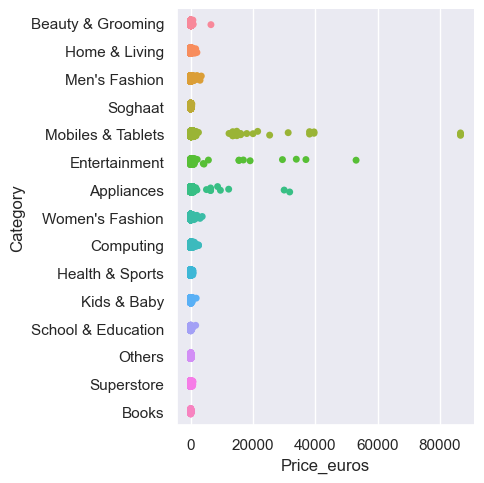

In [23]:
plt.figure(figsize = (10,10))
sns.catplot(data =df, y="Category", x="Price_euros");

In [24]:
df["Price_euros"].describe()

count    106378.000000
mean         77.882200
std         654.364114
min           0.010000
25%           2.960000
50%           8.620000
75%         104.490000
max       86597.000000
Name: Price_euros, dtype: float64

## <center>Data Storytelling</center>

##### Etude des 'Statuts' au cours des années

In [25]:
annees = df['Year'].unique()

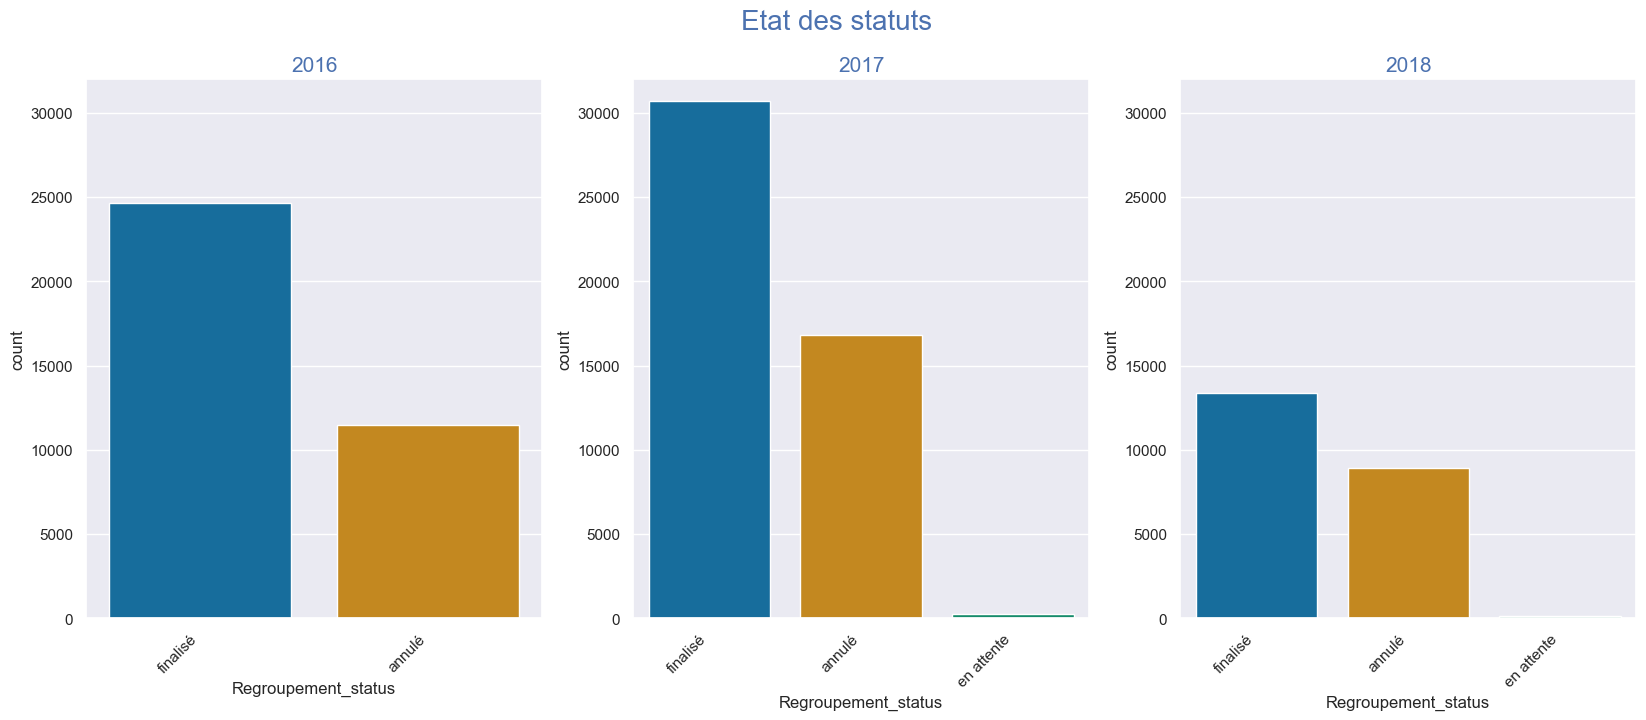

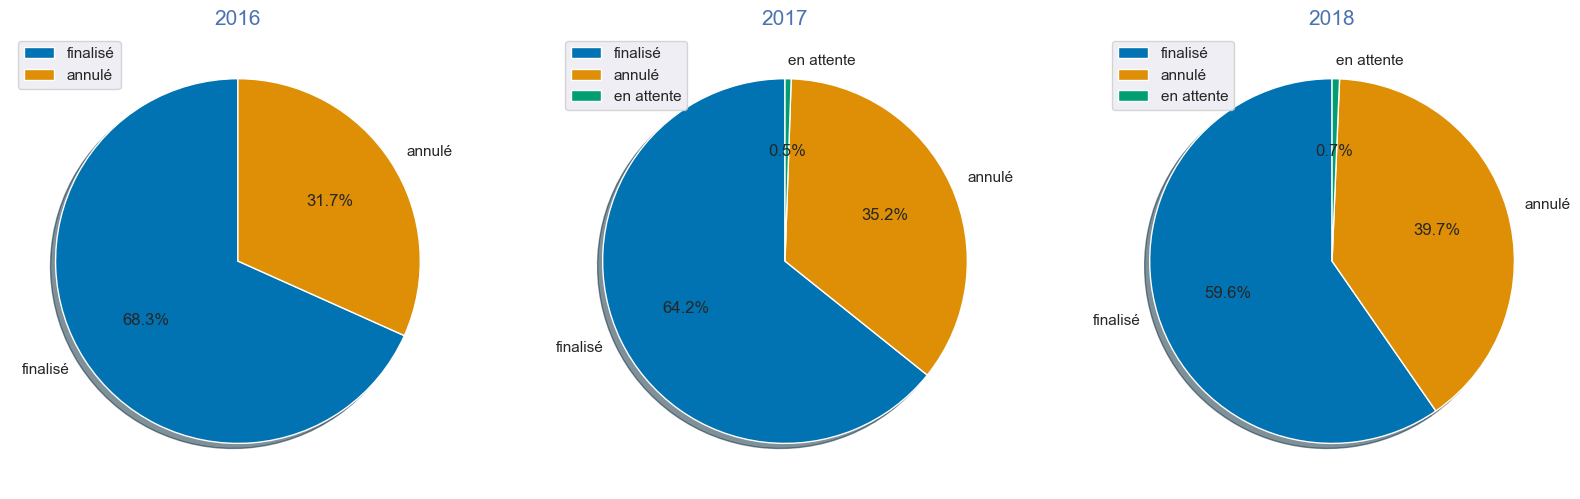

In [26]:
colors = ['#0173b2', '#de8f05', '#029e73', '#d55e00', '#8172b3']

labels = ['finalisé', 'annulé', 'en attente']
colors1 ={'finalisé':'#0173b2','annulé':'#de8f05','en attente':'#029e73'}
          
plt.figure(figsize=(20, 7))
for i in range(3):
    plt.subplot(1, 3, (i+1))
    sns.countplot(df[df['Year']==annees[i]]['Regroupement_status'], palette=colors1)
    plt.xticks(rotation=45, horizontalalignment='right')
    plt.title(('{}').format(annees[i]), fontsize=15, color='b')
    plt.ylim(0,32000)
plt.suptitle('Etat des statuts', fontsize=20, color='b');

plt.figure(figsize=(20, 10))
for i in range(3):
    plt.subplot(1, 3, (i+1))
    plt.pie(df[df['Year']==annees[i]]['Regroupement_status'].value_counts(), 
            labels=df[df['Year']==annees[i]]['Regroupement_status'].unique(),
            autopct='%1.1f%%',colors = colors, shadow=True, startangle=90)
    plt.title(('{}').format(annees[i]), fontsize=15, color='b')
    plt.legend(loc='best');

Nous constatons une évolution négative de 12.73% des commandes finalisées, et une moyenne de 35.53% des commandes annulées de 2016 à 2018.

De plus, nous voyons également l'apparition en 2017 de commandes en attente, dont la quantité reste inférieure à 1%.

##### Etude des 'payment_method' au cours des années

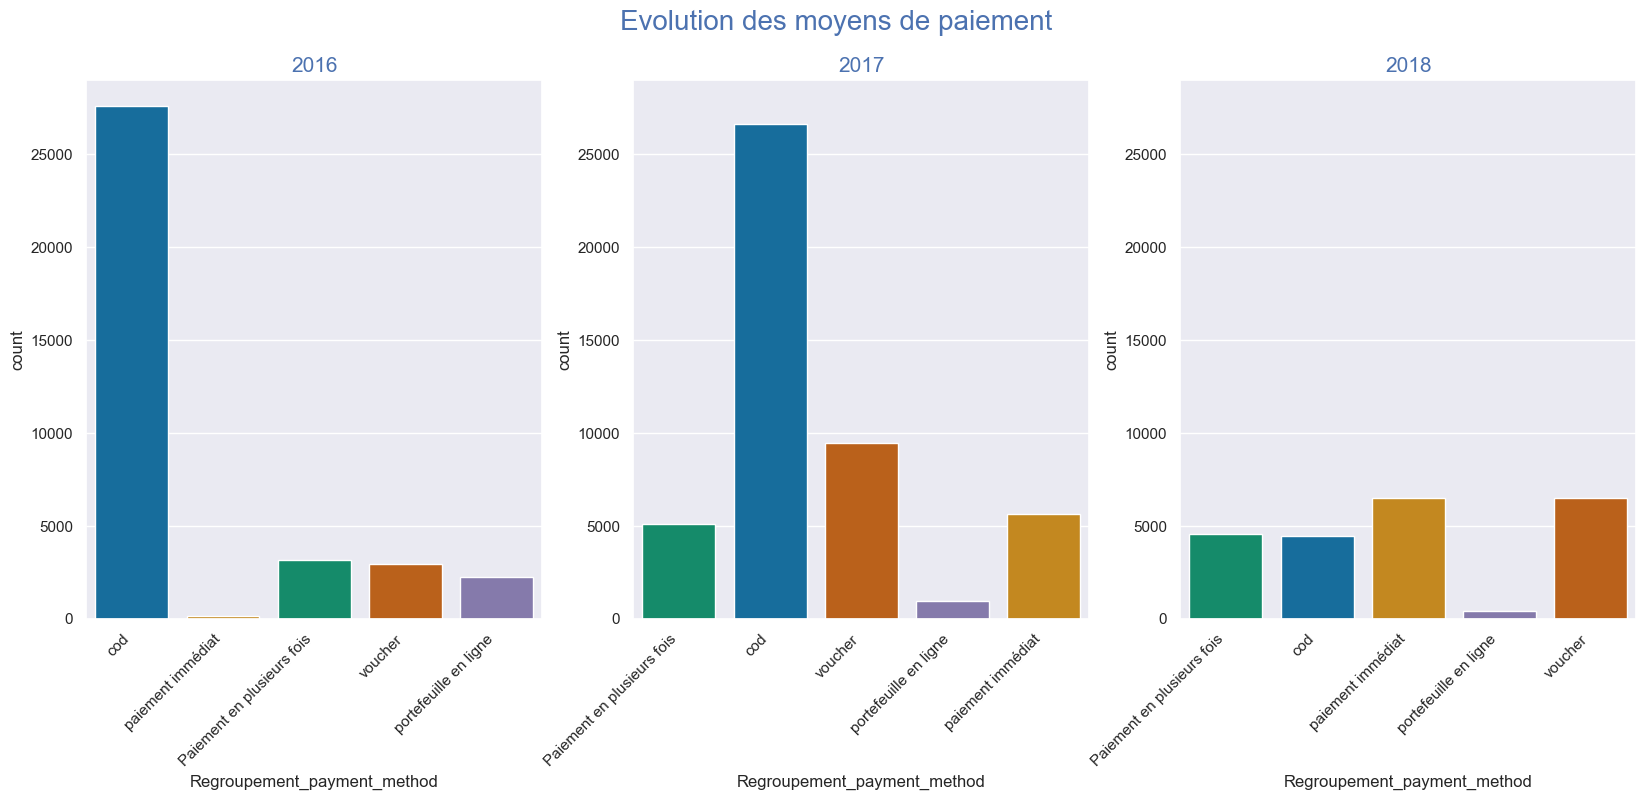

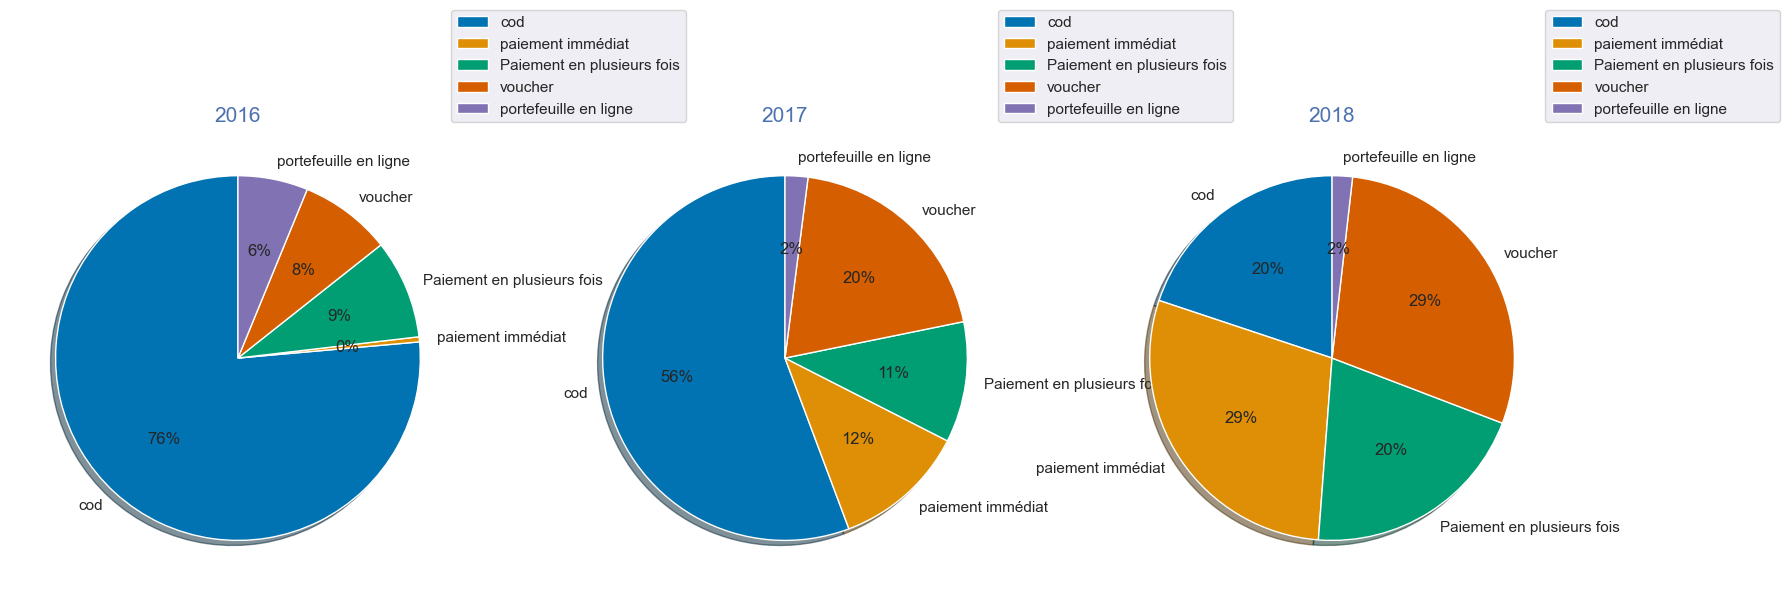

In [27]:
colors = ['#0173b2', '#de8f05', '#029e73', '#d55e00', '#8172b3']

labels = ['cod', 'paiement immédiat', 'Paiement en plusieurs fois', 'voucher','portefeuille en ligne']
colors1 ={'cod':'#0173b2','paiement immédiat':'#de8f05','Paiement en plusieurs fois':'#029e73','voucher':'#d55e00','portefeuille en ligne':'#8172b3'}


plt.figure(figsize=(20, 7))

for i in range(3):
    plt.subplot(1, 3, (i+1))
    sns.countplot(df[df['Year']==annees[i]]['Regroupement_payment_method'], palette=colors1)
    plt.xticks(rotation=45, horizontalalignment='right')
    plt.title(('{}').format(annees[i]), fontsize=15, color='b')
    plt.ylim(0,29000)
plt.suptitle('Evolution des moyens de paiement', fontsize=20, color='b');

plt.figure(figsize=(20, 10))
for i in range(3):
    plt.subplot(1, 3, (i+1))
    plt.pie(df[df['Year']==annees[i]]['Regroupement_payment_method'].value_counts(normalize=True).reindex(labels),
            labels=df[df['Year']==annees[i]]['Regroupement_payment_method'].value_counts(normalize=True).reindex(labels).index,
            autopct='%1.0f%%',colors = colors,shadow=True, startangle=90)


    plt.title(('{}').format(annees[i]), fontsize=15, color="b")
    plt.legend(loc=4, bbox_to_anchor=(1.5, 1));

In [28]:
df['Year']==2016

0          True
1          True
2          True
3          True
4          True
          ...  
106733    False
106734    False
106735    False
106736    False
106737    False
Name: Year, Length: 106378, dtype: bool

Nous voyons ici une évolution significative des moyens de paiement de la population pakistanaise.

Au fil des années, la digitalisation des méthodes de paiement a permis l'émergence de nouveaux modes de réglement 

Exemple: portefeuille en ligne augmente de 40% sur la période 2016 - 2018.

##### Etude des ventes au cours des années

In [29]:
mean_sales = df.groupby('Created_at', as_index=False).agg({'Net_income_euros':'mean'})
median_sales = df.groupby('Created_at', as_index=False).agg({'Net_income_euros':'median'})

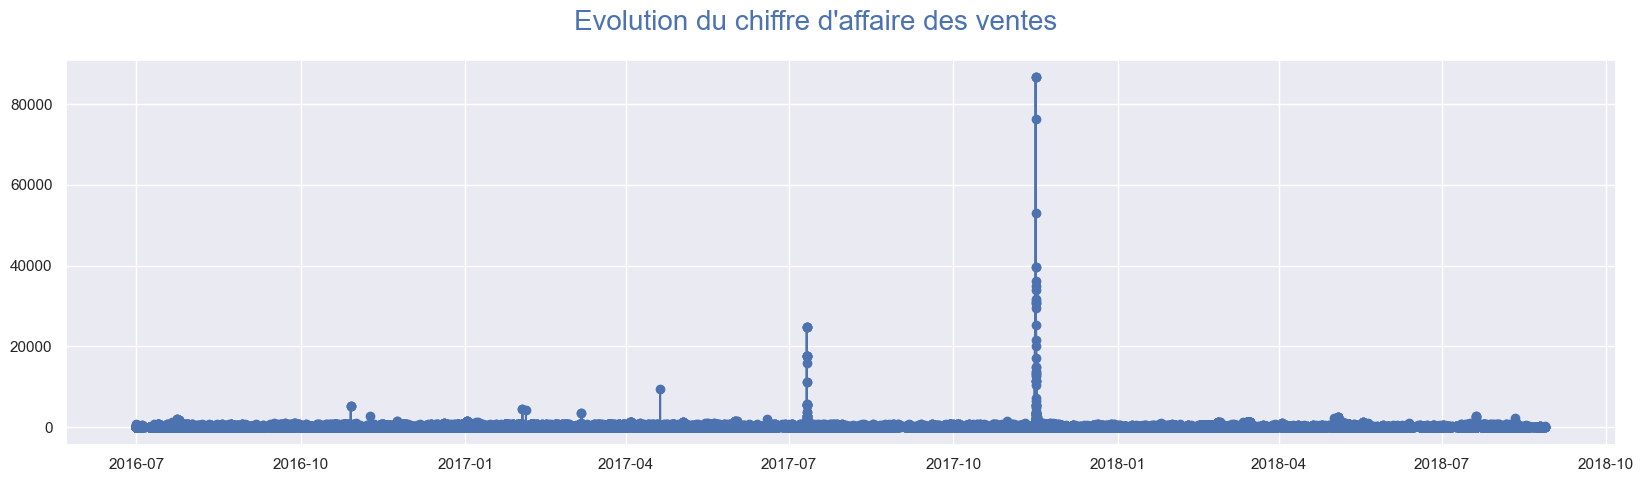

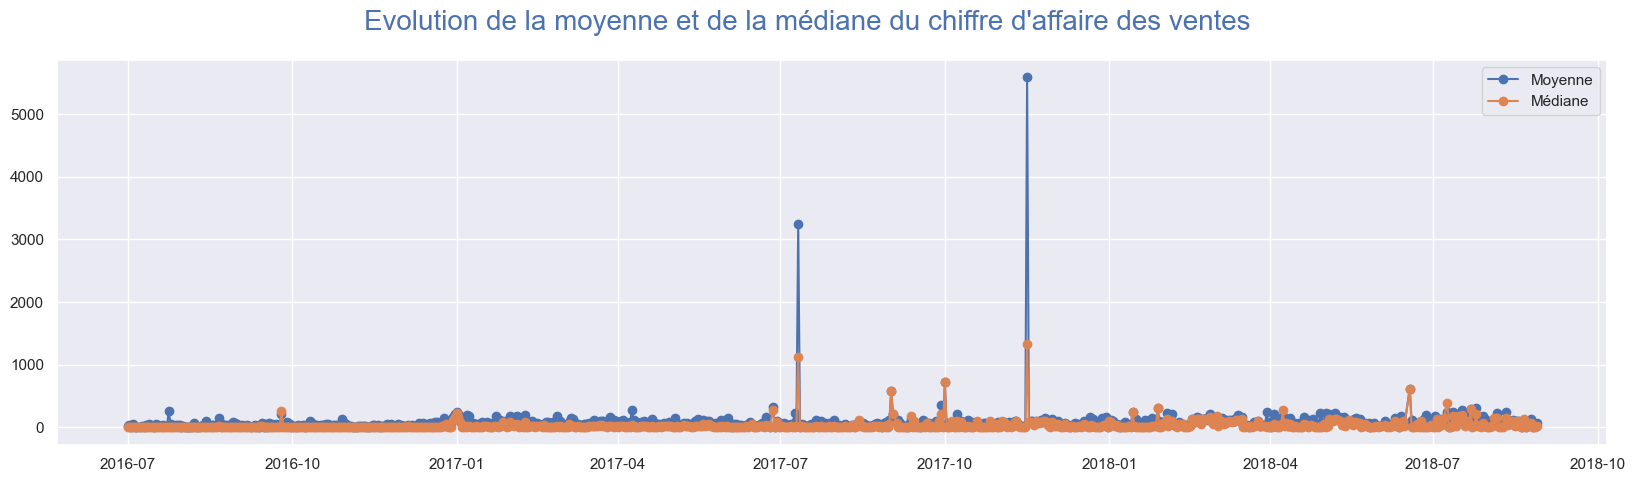

In [30]:
plt.figure(figsize=(20,5))
plt.plot_date(df['Created_at'], df['Net_income_euros'], xdate=True, ls='-')
plt.suptitle('Evolution du chiffre d\'affaire des ventes', fontsize=20, color='b');

plt.figure(figsize = (20,5))
plt.plot_date(mean_sales["Created_at"], mean_sales['Net_income_euros'], 
              xdate=True, 
              ls='-', label='Moyenne')
plt.plot_date(median_sales["Created_at"], median_sales['Net_income_euros'], 
              xdate=True, 
              ls='-', label='Médiane')
plt.legend()
plt.suptitle('Evolution de la moyenne et de la médiane du chiffre d\'affaire des ventes', fontsize=20, color='b');




Nous constatons qu'en dehors de l'année 2017 qui présente des pics d'activités exceptionnels sur les mois de mai, juillet et novembre notamment, le chiffre d'affaires est plutôt homogène.

Compte tenu de l'évolution moindre de la médiane comparativement à la moyenne, nous concluons qu'il s'agit d'une infime minorité d'opérations qui entraine une hausse ponctuelle du chiffre d'affaires.  

##### <center>Modèle de régression appliqué aux ventes (variable net_income_euros)</center>

In [31]:
# Création d'un nouveau DataFrame df_reg qui ne comporte que les colonnes qui nous seront utiles

df_reg = df.drop(['Customer since', 'Price', 'Discount_amount', 'Net_income', 'Payment_method',
                 'Created_at', 'Status', 'Taux_change'], axis=1)

In [32]:
df_reg.head(3)

,Customer_id,Item_id,Increment_id,Sales_commission_code,Qty_ordered,Year,Month,Category,Bi_status,Regroupement_status,Regroupement_payment_method,Discount_amount_euros,Net_income_euros,Price_euros
0,4,211135,100147446,R-FSD-52352,1,2016,7,Beauty & Grooming,Net,finalisé,cod,2.61,0.52,3.13
1,11,211145,100147455,105259,1,2016,7,Home & Living,Net,finalisé,paiement immédiat,0.00,1.04,1.04
2,11,211147,100147457,105259,1,2016,7,Men's Fashion,Gross,annulé,paiement immédiat,0.00,13.46,13.46


Numérisation des variables Customer_ID, item_id, sales_commission_code, category, regroupement_status et regroupement_payment_method afin de pouvoir appliquer la régression linéaire à df_reg, et suppression des variables non numériques.

In [33]:
# Customer_ID

Customer_ID_num = df_reg['Customer_id']
for i, j in enumerate(df_reg['Customer_id'].unique()):
    Customer_ID_num = Customer_ID_num.replace({j:i})

df_reg['Customer_id_num'] = Customer_ID_num

In [34]:
# category

category_num = df_reg['Category']
for i, j in enumerate(df_reg['Category'].unique()):
    category_num = category_num.replace({j:i})

df_reg['Category_num'] = category_num

In [35]:
# item_id

item_id_num = df_reg['Item_id']
for i, j in enumerate(df_reg['Item_id'].unique()):
    item_id_num = item_id_num.replace({j:i})

df_reg['Item_id_num'] = item_id_num

In [36]:
# sales_commission_code

sales_commission_code_num = df_reg['Sales_commission_code']
for i, j in enumerate(df_reg['Sales_commission_code'].unique()):
    sales_commission_code_num = sales_commission_code_num.replace({j:i})

df_reg['Sales_commission_code_num'] = sales_commission_code_num

In [37]:
# regroupement_status

regroupement_status_num = df_reg['Regroupement_status']
for i, j in enumerate(df_reg['Regroupement_status'].unique()):
    regroupement_status_num = regroupement_status_num.replace({j:i})

df_reg['Regroupement_status_num'] = regroupement_status_num

In [38]:
# regroupement_payment_method

regroupement_payment_method_num = df_reg['Regroupement_payment_method']
for i, j in enumerate(df_reg['Regroupement_payment_method'].unique()):
    regroupement_payment_method_num = regroupement_payment_method_num.replace({j:i})

df_reg['Regroupement_payment_method_num'] = regroupement_payment_method_num

In [39]:
# Suppression des variables non numériques

df_reg = df_reg.drop(['Customer_id', 'Item_id', 'Category', 'Sales_commission_code', 
                      'Regroupement_status', 'Regroupement_payment_method'], axis=1)

,Increment_id,Qty_ordered,Year,Month,Discount_amount_euros,Net_income_euros,Price_euros,Customer_id_num,Category_num,Item_id_num,Sales_commission_code_num,Regroupement_status_num,Regroupement_payment_method_num
Increment_id,1.000000,0.045731,0.927029,-0.286233,0.172887,0.049393,0.051647,0.816914,0.229848,0.995894,0.490490,0.073679,0.361457
Qty_ordered,0.045731,1.000000,0.054439,-0.043694,-0.007372,0.016212,-0.010544,0.026340,0.083072,0.045198,0.022239,-0.015256,-0.010153
Year,0.927029,0.054439,1.000000,-0.613179,0.147819,0.047109,0.046042,0.735749,0.225055,0.926073,0.441423,0.069717,0.262625
Month,-0.286233,-0.043694,-0.613179,1.000000,-0.011024,-0.010241,-0.003478,-0.175008,-0.103456,-0.288853,-0.108599,-0.022793,0.069259
Discount_amount_euros,0.172887,-0.007372,0.147819,-0.011024,1.000000,0.272095,0.323311,0.183034,0.035639,0.174693,0.050178,0.006537,0.231312
Net_income_euros,0.049393,0.016212,0.047109,-0.010241,0.272095,1.000000,0.942047,0.051233,0.010364,0.050838,0.032328,0.047359,0.039273
Price_euros,0.051647,-0.010544,0.046042,-0.003478,0.323311,0.942047,1.000000,0.054257,0.007495,0.053004,0.032796,0.044267,0.051978
Customer_id_num,0.816914,0.026340,0.735749,-0.175008,0.183034,0.051233,0.054257,1.000000,0.171047,0.808564,0.476770,0.072781,0.387907
Category_num,0.229848,0.083072,0.225055,-0.103456,0.035639,0.010364,0.007495,0.171047,1.000000,0.237590,0.112550,0.037689,0.173152
Item_id_num,0.995894,0.045198,0.926073,-0.288853,0.174693,0.050838,0.053004,0.808564,0.237590,1.000000,0.494341,0.073943,0.365986


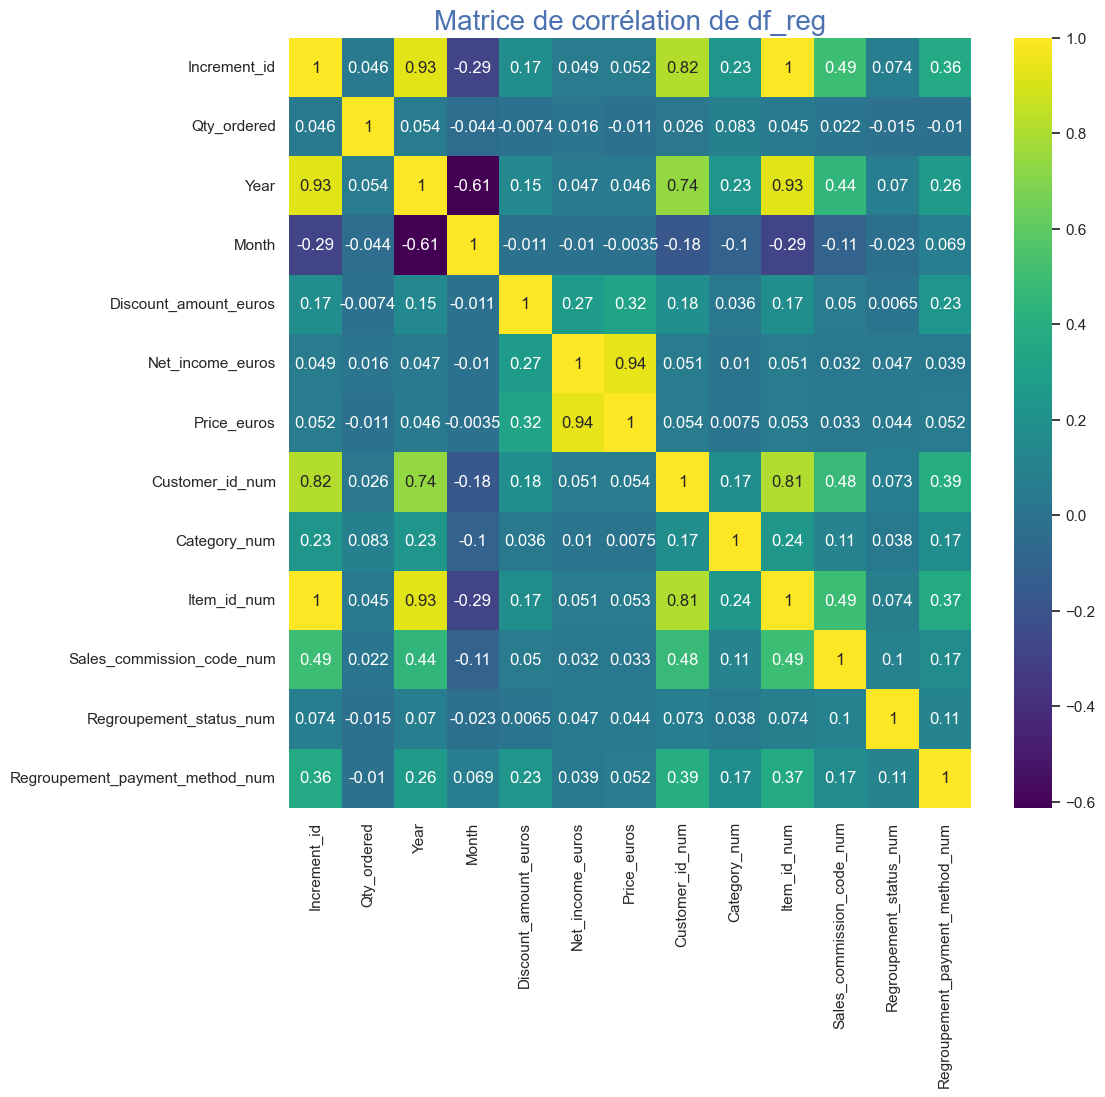

In [40]:
# Affichage du tableau et de la matrice de corrélation

display(df_reg.corr())

plt.figure(figsize=(11, 10))
sns.heatmap(df_reg.corr(), annot=True, cmap='viridis')
plt.title('Matrice de corrélation de df_reg', fontsize=20, color='b');

La seule variable ayant une corrélation évidente avec la variable net_income_euros est la variable price_euros.

Pour cela, nous allons calculer un modèle de régression simple entre net_income_euros et price_euros, net_income_euros étant notre variable cible.

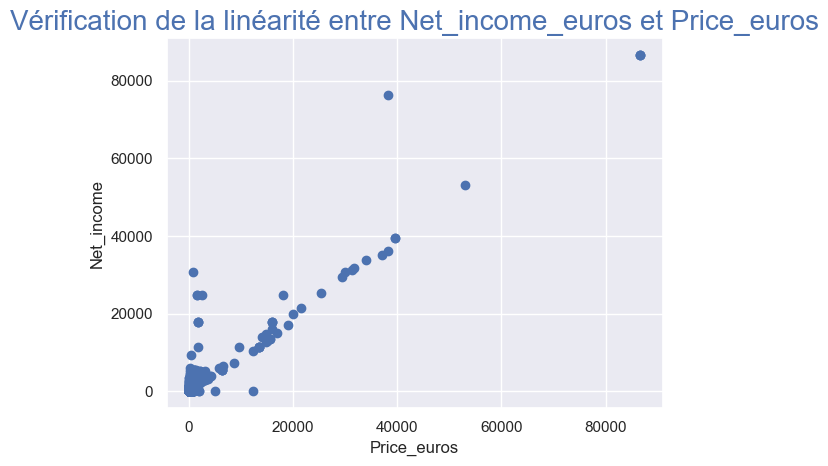

In [41]:
# Vérification de la linéarité entre net_income_euros et price_euros

plt.scatter(df_reg['Price_euros'], df['Net_income_euros'])
plt.xlabel("Price_euros")
plt.ylabel("Net_income")
plt.title('Vérification de la linéarité entre Net_income_euros et Price_euros', fontsize=20, color='b');

Il y a bien une relation de linéarité entre "Net_income" et "Price_euros"

In [42]:
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.linear_model import LinearRegression

In [43]:
# Création des vecteurs

X = df_reg[['Price_euros']]
y = df_reg['Net_income_euros']

In [44]:
# Instantiation et ajustement du modèle de régression linéaire

slr = LinearRegression().fit(X, y)

In [45]:
print('intercept :', slr.intercept_)
print('coef :', slr.coef_)

intercept : 7.580077216601552
coef : [1.02910026]


In [46]:
# Evaluation du modèle slr par validation croisée à 4 échantillons

cross_validate(slr, X, y, return_train_score=True, cv=4)

{'fit_time': array([0.0042522 , 0.00390911, 0.00348902, 0.00367212]),
 'score_time': array([0.00142598, 0.00099587, 0.00075197, 0.00076318]),
 'test_score': array([0.7179276 , 0.64733834, 0.89389447, 0.68127651]),
 'train_score': array([0.8882704 , 0.89090292, 0.69166472, 0.88969773])}

In [47]:
print('moyenne score train :', cross_validate(slr, X, y, return_train_score=True, cv=4)['train_score'].mean())
print('moyenne score test :', cross_validate(slr, X, y, return_train_score=True, cv=4)['test_score'].mean())

moyenne score train : 0.8401339435585515
moyenne score test : 0.7351092307224809


In [48]:
# Calcul des valeurs ajustées

pred_y = slr.predict(X)
residus = pred_y - y


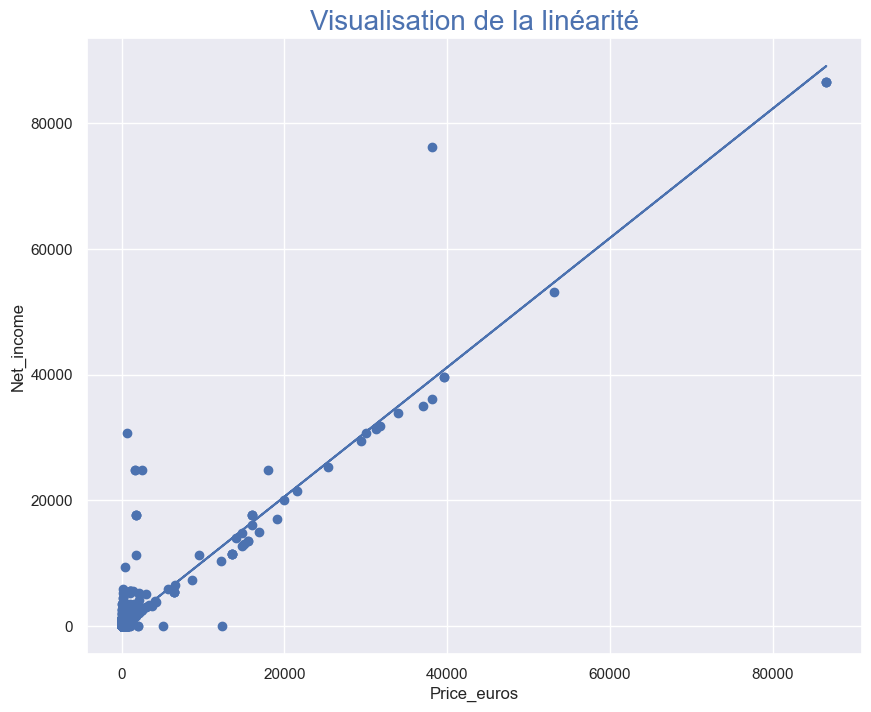

In [49]:
# Affichage de la droite de régression
plt.figure(figsize=(10, 8))

plt.scatter(X, y)
plt.plot(X, pred_y)
plt.xlabel("Price_euros")
plt.ylabel("Net_income")
plt.title('Visualisation de la linéarité', fontsize=20, color='b');

La droite de régression semble raisonnablement ajustée, quelques points sont plus éloignés de la droite, notamment ceux avec un prix élevé, mais l'ensemble reste relativement correct.

Les valeurs aberrantes peuvent avoir une grande influence sur les modèles de régression linéaire : puisque le propre de la régression est la minimisation des résidus au carré, les résidus importants ont une influence disproportionnée sur le modèle.

L'affichage de la droite nous aide à détecter les valeurs aberrantes influentes. Dans notre graphique, il ne semble pas y avoir de valeurs aberrantes influentes.

Dans le cadre des objectifs fixés pour la suite de notre projet, nous avons décidé d'axer nos analyses sur le comportement client ("Customer_id"). Par conséquent nous ne développons pas plus les analyses sur les variables cibles étudiées précédemment.

In [50]:
df.to_csv("exploration.csv",index=False)